##Análisis del Dato — HAM10000 (Lesiones Cutáneas)
#Los 3 modelos  están interrumpidos porque ya se entrenaron antes y se cargados justo después de la definición del CNN, para no volver a reentrenar otra vez

Ejecutar en Google Colab con GPU (Runtime → Change runtime type → T4 GPU) o mejor con el A100 de Google Colab Pro

---

## Índice

2. Carga de Datos y Configuración
3. Modelo A (Línea Base): ResNet-50
4. Modelo B (Avanzado): EfficientNet-B3
5. Métricas de Evaluación
6. Visualización del Modelo
7. Interpretación de Resultados
8. Conclusiones

---
## 2. Carga de Datos y Configuración

In [8]:
# ============================================
# MONTAJE DE DRIVE Y CONFIGURACIÓN GENERAL
# ============================================
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/HAM10000'
IMG_PART1 = f'{BASE_PATH}/HAM10000_images_part_1'
IMG_PART2 = f'{BASE_PATH}/HAM10000_images_part_2'
METADATA_PATH = f'{BASE_PATH}/ham10000_metadata_clean.csv'  # Del notebook de Ingeniería del Dato

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, roc_auc_score, roc_curve, auc,
    precision_score, recall_score
)
from sklearn.preprocessing import label_binarize
import time
import copy

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dispositivo: cuda
GPU: NVIDIA A100-SXM4-40GB
Memoria: 42.4 GB


In [9]:
import shutil
LOCAL_PATH = '/content/HAM10000'          # Carpeta en el disco local de Colab
os.makedirs(LOCAL_PATH, exist_ok=True)    # Crearla si no existe

if not os.path.exists(f'{LOCAL_PATH}/images_done.flag'):
    # Si NO existe el archivo "flag", significa que aún no hemos copiado

    for folder in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
        src = f'{BASE_PATH}/{folder}'     # Origen: Drive (lento)
        dst = f'{LOCAL_PATH}/{folder}'    # Destino: disco local (rápido)
        shutil.copytree(src, dst)         # Copia toda la carpeta con sus 5000 imágenes

    shutil.copy(f'{BASE_PATH}/ham10000_metadata_clean.csv', f'{LOCAL_PATH}/')                     # Copia también el CSV del metadata

    open(f'{LOCAL_PATH}/images_done.flag', 'w').close()
    # Crea un archivo vacío como "bandera" para saber que ya copiamos
    # Así si vuelves a ejecutar la celda, no copia de nuevo

else:
    print('Ya copiadas.')                 # Si el flag existe, no hace nada

# Actualizar rutas para que el resto del notebook lea del local
IMG_PART1 = f'{LOCAL_PATH}/HAM10000_images_part_1'   # Ahora apunta al local
METADATA_PATH = f'{LOCAL_PATH}/ham10000_metadata_clean.csv'

Ya copiadas.


In [10]:
# ============================================
# CARGAR METADATA LIMPIO + CONSTANTES
# ============================================
df = pd.read_csv(METADATA_PATH)
df['image_path'] = df['image_path'].str.replace('/content/drive/MyDrive/HAM10000', LOCAL_PATH)
print(f'Dataset: {len(df)} imágenes, {df["dx"].nunique()} clases')
print(f'Splits: {df["split"].value_counts().to_dict()}')

# Constantes (mismas que en Ingeniería del Dato)
IMG_SIZE = 224
NUM_CLASSES = 7
BATCH_SIZE = 32

CLASS_NAMES = {
    'nv': 'Melanocytic nevi', 'mel': 'Melanoma',
    'bkl': 'Benign keratosis', 'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses', 'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
CLASS_COLORS = {
    'nv': 'steelblue', 'mel': 'crimson', 'bkl': 'teal',
    'bcc': 'darkorange', 'akiec': 'mediumpurple',
    'vasc': 'forestgreen', 'df': 'goldenrod'
}
class_to_idx = {cls: i for i, cls in enumerate(sorted(CLASS_NAMES.keys()))}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f'\nMapeo de clases: {class_to_idx}')

Dataset: 10015 imágenes, 7 clases
Splits: {'train': 7002, 'test': 1508, 'val': 1505}

Mapeo de clases: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [11]:
# ============================================
# DATASET Y DATALOADERS
# ============================================
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        label = class_to_idx[row['dx']]
        if self.transform:
            img = self.transform(img)
        return img, label

# Transformaciones
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Crear datasets
train_dataset = HAM10000Dataset(df[df['split']=='train'], transform=train_transforms)
val_dataset   = HAM10000Dataset(df[df['split']=='val'],   transform=val_test_transforms)
test_dataset  = HAM10000Dataset(df[df['split']=='test'],  transform=val_test_transforms)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

# Weighted Sampler para desbalanceo en train
train_labels = [class_to_idx[dx] for dx in df[df['split']=='train']['dx']]
class_counts_train = Counter(train_labels)
total = sum(class_counts_train.values())
class_weights = {cls: total / count for cls, count in class_counts_train.items()}
sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

Train: 7002 | Val: 1505 | Test: 1508


---
## 3. Funciones de Entrenamiento y Evaluación

Definimos funciones reutilizables para ambos modelos. Esto permite comparar los resultados de forma justa, ya que ambos siguen exactamente el mismo protocolo de entrenamiento.

In [39]:
# ============================================
# FUNCIÓN DE ENTRENAMIENTO CON EARLY STOPPING
# ============================================
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs=30, patience=7, model_name='model'):
    """
    Entrena el modelo con early stopping.
    Devuelve el mejor modelo, historial de métricas y el epoch donde paró.
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    best_epoch = 0

    print(f'\n{"="*60}')
    print(f'  Entrenando: {model_name}')
    print(f'{"="*60}')

    for epoch in range(num_epochs):
        start = time.time()

        # --- TRAIN ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # --- VALIDATION ---
        model.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = correct / total

        # Scheduler step
        # Scheduler step
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        elif scheduler:
            scheduler.step()

        # Guardar historial
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        elapsed = time.time() - start
        print(f'Epoch {epoch+1:02d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
              f'{elapsed:.1f}s', end='')

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            best_epoch = epoch + 1
            print(' ★ Mejor modelo guardado')
        else:
            epochs_no_improve += 1
            print(f' (sin mejora: {epochs_no_improve}/{patience})')
            if epochs_no_improve >= patience:
                print(f'\n→ Early stopping en epoch {epoch+1}. Mejor epoch: {best_epoch}')
                break

    model.load_state_dict(best_model_wts)
    return model, history, best_epoch

In [13]:
# ============================================
# FUNCIÓN DE EVALUACIÓN EN TEST
# ============================================
def evaluate_model(model, test_loader, model_name='model'):
    """
    Evalúa el modelo en el set de test.
    Devuelve labels reales, predicciones y probabilidades.
    """
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    print(f'\n{"="*60}')
    print(f'  Resultados en TEST: {model_name}')
    print(f'{"="*60}')

    # Métricas globales
    acc = accuracy_score(all_labels, all_preds)
    f1_w = f1_score(all_labels, all_preds, average='weighted')
    f1_m = f1_score(all_labels, all_preds, average='macro')
    precision_w = precision_score(all_labels, all_preds, average='weighted')
    recall_w = recall_score(all_labels, all_preds, average='weighted')

    # AUC-ROC (One-vs-Rest)
    labels_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
    try:
        auc_ovr = roc_auc_score(labels_bin, all_probs, average='weighted', multi_class='ovr')
    except:
        auc_ovr = float('nan')

    print(f'Accuracy:           {acc:.4f}')
    print(f'F1-Score (weighted): {f1_w:.4f}')
    print(f'F1-Score (macro):    {f1_m:.4f}')
    print(f'Precision (weighted):{precision_w:.4f}')
    print(f'Recall (weighted):   {recall_w:.4f}')
    print(f'AUC-ROC (weighted):  {auc_ovr:.4f}')

    # Classification report por clase
    target_names = [f'{idx_to_class[i]} ({CLASS_NAMES[idx_to_class[i]]})' for i in range(NUM_CLASSES)]
    print(f'\n{classification_report(all_labels, all_preds, target_names=target_names)}')

    metrics = {
        'accuracy': acc, 'f1_weighted': f1_w, 'f1_macro': f1_m,
        'precision_weighted': precision_w, 'recall_weighted': recall_w,
        'auc_roc': auc_ovr
    }
    return all_labels, all_preds, all_probs, metrics

In [14]:
print(df['image_path'].iloc[0])
import time
from PIL import Image

# Test: leer 100 imágenes y medir tiempo
paths = df['image_path'].head(100).tolist()
start = time.time()
for p in paths:
    img = Image.open(p).convert('RGB')
elapsed = time.time() - start
print(f'100 imágenes en {elapsed:.1f}s ({elapsed/100*1000:.0f}ms por imagen)')

/content/HAM10000/HAM10000_images_part_1/ISIC_0027419.jpg
100 imágenes en 0.5s (5ms por imagen)


---
## 3.5 Modelo 0 (Baseline Naive): CNN desde cero (sin Transfer Learning)

Antes de aplicar transfer learning, entrenamos una CNN sencilla **desde cero** para establecer un punto de referencia y demostrar empíricamente cuánto aporta el transfer learning.

Esta red tiene una arquitectura simple: 4 bloques convolucionales con batch normalization y max pooling, seguidos de una capa fully connected. Con ~2.5M de parámetros, es mucho más pequeña que ResNet-50 (25.6M) o EfficientNet-B3 (12M), pero todos sus pesos se inicializan aleatoriamente — no aprovecha ningún conocimiento previo.

**Hipótesis:** Con solo ~10.000 imágenes, esperamos que esta red sufra overfitting y obtenga resultados significativamente peores que los modelos con transfer learning.

In [17]:
# ============================================
# CARGAR TODOS LOS MODELOS DESDE DRIVE (sin reentrenar)
# ============================================

# --- CNN Scratch ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(SimpleCNN, self).__init__()
        self.block1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(True),nn.Conv2d(32,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(True),nn.MaxPool2d(2,2))
        self.block2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(True),nn.Conv2d(64,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(True),nn.MaxPool2d(2,2))
        self.block3 = nn.Sequential(nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(True),nn.Conv2d(128,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(True),nn.MaxPool2d(2,2))
        self.block4 = nn.Sequential(nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(True),nn.Conv2d(256,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(True),nn.AdaptiveAvgPool2d((1,1)))
        self.classifier = nn.Sequential(nn.Flatten(),nn.Dropout(0.4),nn.Linear(256,128),nn.ReLU(True),nn.Dropout(0.3),nn.Linear(128,num_classes))
    def forward(self, x):
        return self.classifier(self.block4(self.block3(self.block2(self.block1(x)))))

cnn_scratch = SimpleCNN(num_classes=NUM_CLASSES).to(device)
cnn_scratch.load_state_dict(torch.load(f'{BASE_PATH}/cnn_scratch.pth', map_location=device, weights_only=False))
labels_scratch, preds_scratch, probs_scratch, metrics_scratch = evaluate_model(cnn_scratch, test_loader, 'CNN Scratch')

# --- ResNet-50 ---
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Sequential(nn.Dropout(0.3),nn.Linear(num_ftrs,512),nn.ReLU(),nn.Dropout(0.2),nn.Linear(512,NUM_CLASSES))
resnet = resnet.to(device)
resnet.load_state_dict(torch.load(f'{BASE_PATH}/modelo_baseline_resnet50.pth', map_location=device, weights_only=False)['model_state_dict'])
labels_resnet, preds_resnet, probs_resnet, metrics_resnet = evaluate_model(resnet, test_loader, 'ResNet-50')

# --- EfficientNet-B3 ---
efficientnet = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
num_ftrs = efficientnet.classifier[1].in_features
efficientnet.classifier = nn.Sequential(nn.Dropout(0.3),nn.Linear(num_ftrs,512),nn.ReLU(),nn.Dropout(0.2),nn.Linear(512,NUM_CLASSES))
efficientnet = efficientnet.to(device)
efficientnet.load_state_dict(torch.load(f'{BASE_PATH}/modelo_final_efficientnet_b3.pth', map_location=device, weights_only=False)['model_state_dict'])
labels_effnet, preds_effnet, probs_effnet, metrics_effnet = evaluate_model(efficientnet, test_loader, 'EfficientNet-B3')

print('\n✅ Los 3 modelos cargados. Sin reentrenar nada.')


  Resultados en TEST: CNN Scratch
Accuracy:           0.4562
F1-Score (weighted): 0.5250
F1-Score (macro):    0.2798
Precision (weighted):0.7153
Recall (weighted):   0.4562
AUC-ROC (weighted):  0.8243

                            precision    recall  f1-score   support

 akiec (Actinic keratoses)       0.18      0.80      0.29        44
bcc (Basal cell carcinoma)       0.19      0.32      0.24        71
    bkl (Benign keratosis)       0.29      0.19      0.23       154
       df (Dermatofibroma)       0.05      0.19      0.07        16
            mel (Melanoma)       0.30      0.49      0.37       166
     nv (Melanocytic nevi)       0.93      0.49      0.64      1034
   vasc (Vascular lesions)       0.06      0.57      0.11        23

                  accuracy                           0.46      1508
                 macro avg       0.29      0.43      0.28      1508
              weighted avg       0.72      0.46      0.52      1508


  Resultados en TEST: ResNet-50
Accuracy:    

In [52]:
# ============================================
# MODELO 0: CNN FROM SCRATCH (sin Transfer Learning)
# ============================================
pass
class SimpleCNN(nn.Module):
    """
    CNN sencilla de 4 bloques convolucionales.
    Sirve como baseline para cuantificar el impacto del transfer learning.
    """
    def __init__(self, num_classes=7):
        super(SimpleCNN, self).__init__()
        # Bloque 1: 3 -> 32 canales
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  # 224 -> 112
        )
        # Bloque 2: 32 -> 64 canales
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  # 112 -> 56
        )
        # Bloque 3: 64 -> 128 canales
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  # 56 -> 28
        )
        # Bloque 4: 128 -> 256 canales
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))  # 28 -> 1
        )
        # Clasificador
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x

# Instanciar
cnn_scratch = SimpleCNN(num_classes=NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in cnn_scratch.parameters())
trainable = sum(p.numel() for p in cnn_scratch.parameters() if p.requires_grad)
print(f'Parámetros totales: {total_params:,}')
print(f'Parámetros entrenables: {trainable:,} (todos — no hay pesos preentrenados)')

# Optimizador y scheduler
optimizer_scratch = optim.Adam(cnn_scratch.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_scratch = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_scratch, mode='min', patience=3, factor=0.5
)
# Loss function con pesos para desbalanceo
class_weights_tensor = torch.tensor(
    [class_weights[i] for i in range(NUM_CLASSES)], dtype=torch.float
).to(device)
criterion = nn.CrossEntropyLoss()
# Entrenar
cnn_scratch, history_scratch, _ = train_model(
    cnn_scratch, train_loader, val_loader, criterion, optimizer_scratch, scheduler_scratch,
    num_epochs=30, patience=7, model_name='CNN From Scratch (sin Transfer Learning)'
)

Parámetros totales: 1,207,975
Parámetros entrenables: 1,207,975 (todos — no hay pesos preentrenados)

  Entrenando: CNN From Scratch (sin Transfer Learning)
Epoch 01/30 | Train Loss: 1.7915 Acc: 0.2674 | Val Loss: 1.4927 Acc: 0.4399 | 29.9s ★ Mejor modelo guardado
Epoch 02/30 | Train Loss: 1.7450 Acc: 0.2939 | Val Loss: 1.3449 Acc: 0.5150 | 29.7s ★ Mejor modelo guardado
Epoch 03/30 | Train Loss: 1.7062 Acc: 0.3223 | Val Loss: 1.6320 Acc: 0.4299 | 29.5s (sin mejora: 1/7)
Epoch 04/30 | Train Loss: 1.6276 Acc: 0.3646 | Val Loss: 1.3361 Acc: 0.4419 | 29.8s ★ Mejor modelo guardado
Epoch 05/30 | Train Loss: 1.5707 Acc: 0.3957 | Val Loss: 1.6051 Acc: 0.3030 | 29.7s (sin mejora: 1/7)


KeyboardInterrupt: 

In [53]:
# Evaluar CNN from scratch en test
labels_scratch, preds_scratch, probs_scratch, metrics_scratch = evaluate_model(
    cnn_scratch, test_loader, 'CNN From Scratch'
)


  Resultados en TEST: CNN From Scratch
Accuracy:           0.4562
F1-Score (weighted): 0.5250
F1-Score (macro):    0.2798
Precision (weighted):0.7153
Recall (weighted):   0.4562
AUC-ROC (weighted):  0.8243

                            precision    recall  f1-score   support

 akiec (Actinic keratoses)       0.18      0.80      0.29        44
bcc (Basal cell carcinoma)       0.19      0.32      0.24        71
    bkl (Benign keratosis)       0.29      0.19      0.23       154
       df (Dermatofibroma)       0.05      0.19      0.07        16
            mel (Melanoma)       0.30      0.49      0.37       166
     nv (Melanocytic nevi)       0.93      0.49      0.64      1034
   vasc (Vascular lesions)       0.06      0.57      0.11        23

                  accuracy                           0.46      1508
                 macro avg       0.29      0.43      0.28      1508
              weighted avg       0.72      0.46      0.52      1508



---
## 4. Modelo A (Línea Base): ResNet-50

ResNet-50 es nuestra línea base. Utiliza conexiones residuales que permiten que el gradiente fluya directamente a través de atajos (skip connections), resolviendo el problema de la degradación en redes profundas. Cada bloque residual calcula $F(x) + x$, donde $F(x)$ es la transformación aprendida y $x$ es la entrada original.

**Estrategia:** Fase 1 con backbone congelado (10 epochs) + Fase 2 con fine-tuning de las últimas capas (20 epochs).

In [54]:
torch.save(cnn_scratch.state_dict(), f'{BASE_PATH}/cnn_scratch.pth')
print('CNN guardado en Drive')

CNN guardado en Drive


In [55]:
# ============================================
# MODELO A: ResNet-50 — Fase 1 (Feature Extraction)
# ============================================
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Congelar todo el backbone
for param in resnet.parameters():
    param.requires_grad = False

# Reemplazar capa clasificadora
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, NUM_CLASSES)
)
resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Solo entrenar la nueva capa fc
optimizer = optim.Adam(resnet.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(f'Parámetros totales: {sum(p.numel() for p in resnet.parameters()):,}')
print(f'Parámetros entrenables: {sum(p.numel() for p in resnet.parameters() if p.requires_grad):,}')

# Fase 1: Feature Extraction
resnet, history_resnet_p1, best_epoch_p1 = train_model(
    resnet, train_loader, val_loader, criterion, optimizer, scheduler,
    num_epochs=15, patience=5, model_name='ResNet-50 (Fase 1: Feature Extraction)'
)

Parámetros totales: 24,560,711
Parámetros entrenables: 1,052,679

  Entrenando: ResNet-50 (Fase 1: Feature Extraction)
Epoch 01/15 | Train Loss: 1.4586 Acc: 0.5131 | Val Loss: 1.1894 Acc: 0.6605 | 29.8s ★ Mejor modelo guardado
Epoch 02/15 | Train Loss: 1.3239 Acc: 0.5764 | Val Loss: 1.1243 Acc: 0.6664 | 29.7s ★ Mejor modelo guardado
Epoch 03/15 | Train Loss: 1.2466 Acc: 0.6168 | Val Loss: 1.1507 Acc: 0.6691 | 29.9s (sin mejora: 1/5)
Epoch 04/15 | Train Loss: 1.2430 Acc: 0.6177 | Val Loss: 1.1834 Acc: 0.6485 | 29.5s (sin mejora: 2/5)
Epoch 05/15 | Train Loss: 1.2085 Acc: 0.6388 | Val Loss: 1.1837 Acc: 0.6372 | 29.6s (sin mejora: 3/5)
Epoch 06/15 | Train Loss: 1.1947 Acc: 0.6395 | Val Loss: 1.1228 Acc: 0.6764 | 29.7s ★ Mejor modelo guardado
Epoch 07/15 | Train Loss: 1.1697 Acc: 0.6617 | Val Loss: 1.2193 Acc: 0.6279 | 29.6s (sin mejora: 1/5)
Epoch 08/15 | Train Loss: 1.1680 Acc: 0.6598 | Val Loss: 1.1203 Acc: 0.6618 | 29.8s ★ Mejor modelo guardado
Epoch 09/15 | Train Loss: 1.1541 Acc: 0.6

KeyboardInterrupt: 

In [ ]:
# ============================================
# MODELO A: ResNet-50 — Fase 2 (Fine-Tuning)
# ============================================
# Descongelar layer4 (últimas capas del backbone)
for param in resnet.layer3.parameters():
    param.requires_grad = True
for param in resnet.layer4.parameters():
    param.requires_grad = True

# Learning rate diferencial: bajo para backbone, más alto para clasificador

optimizer = optim.Adam([
    {'params': resnet.layer3.parameters(), 'lr': 5e-6},
    {'params': resnet.layer4.parameters(), 'lr': 1e-5},
    {'params': resnet.fc.parameters(), 'lr': 1e-4}
])


scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(f'Parámetros entrenables tras descongelar: {sum(p.numel() for p in resnet.parameters() if p.requires_grad):,}')

resnet, history_resnet_p2, best_epoch_p2 = train_model(
    resnet, train_loader, val_loader, criterion, optimizer, scheduler,
    num_epochs=40, patience=10, model_name='ResNet-50 (Fase 2: Fine-Tuning)'
)

# Combinar historiales
history_resnet = {k: history_resnet_p1[k] + history_resnet_p2[k] for k in history_resnet_p1}

In [ ]:
# Evaluar ResNet-50 en test
labels_resnet, preds_resnet, probs_resnet, metrics_resnet = evaluate_model(
    resnet, test_loader, 'ResNet-50'
)

---
## 5. Modelo B (Avanzado): EfficientNet-B3

EfficientNet utiliza **Neural Architecture Search (NAS)** para encontrar una arquitectura base óptima y luego la escala con un coeficiente compuesto que equilibra profundidad ($d = \alpha^\phi$), anchura ($w = \beta^\phi$) y resolución ($r = \gamma^\phi$). La variante B3 ofrece un excelente equilibrio entre rendimiento y eficiencia computacional.

Los bloques MBConv incluyen **squeeze-and-excitation** (SE), que recalibra la importancia de cada canal de features adaptativamente, lo que resulta especialmente útil en imágenes médicas donde ciertos patrones de color son discriminantes.

In [ ]:
train_transforms_eff = transforms.Compose([
    transforms.Resize((IMG_SIZE_EFF, IMG_SIZE_EFF)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),                # 30 → 90
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),  # más agresivo
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.8, 1.2)),    # más rango
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),   # NUEVO
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),    # NUEVO
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15))          # NUEVO - cutout
])

In [45]:
# ============================================
# CAMBIAR TAMAÑO DE IMAGEN PARA EFFICIENTNET (300x300)
# ============================================
IMG_SIZE_EFF = 300
BATCH_SIZE = 64  # antes era 32

train_transforms_eff = transforms.Compose([
    transforms.Resize((IMG_SIZE_EFF, IMG_SIZE_EFF)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transforms_eff = transforms.Compose([
    transforms.Resize((IMG_SIZE_EFF, IMG_SIZE_EFF)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset_eff = HAM10000Dataset(df[df['split']=='train'], transform=train_transforms_eff)
val_dataset_eff   = HAM10000Dataset(df[df['split']=='val'],   transform=val_test_transforms_eff)
test_dataset_eff  = HAM10000Dataset(df[df['split']=='test'],  transform=val_test_transforms_eff)

train_loader_eff = DataLoader(train_dataset_eff, batch_size=BATCH_SIZE, sampler=sampler, num_workers=8, pin_memory=True)
val_loader_eff   = DataLoader(val_dataset_eff,   batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_loader_eff  = DataLoader(test_dataset_eff,  batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)

# Focal Loss — penaliza más los ejemplos difíciles
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print(f'DataLoaders EfficientNet: {IMG_SIZE_EFF}x{IMG_SIZE_EFF}, Focal Loss (gamma=2.0) + label smoothing 0.1')

DataLoaders EfficientNet: 300x300, Focal Loss (gamma=2.0) + label smoothing 0.1


In [44]:
# ============================================
# MODELO B: EfficientNet-B3 — Fase 1 (Feature Extraction)
# ============================================
import torch.nn.functional as F
efficientnet = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

# Congelar backbone
for param in efficientnet.parameters():
    param.requires_grad = False

# Reemplazar clasificador
num_ftrs = efficientnet.classifier[1].in_features
efficientnet.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, NUM_CLASSES)
)
efficientnet = efficientnet.to(device)

optimizer = optim.Adam(efficientnet.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(f'Parámetros totales: {sum(p.numel() for p in efficientnet.parameters()):,}')
print(f'Parámetros entrenables: {sum(p.numel() for p in efficientnet.parameters() if p.requires_grad):,}')

efficientnet, history_eff_p1, _ = train_model(
    efficientnet, train_loader_eff, val_loader_eff, criterion, optimizer, scheduler,
    num_epochs=20, patience=7, model_name='EfficientNet-B3 (Fase 1: Feature Extraction)'
)

Parámetros totales: 11,486,767
Parámetros entrenables: 790,535

  Entrenando: EfficientNet-B3 (Fase 1: Feature Extraction)
Epoch 01/20 | Train Loss: 1.4656 Acc: 0.5071 | Val Loss: 1.1934 Acc: 0.6419 | 27.7s ★ Mejor modelo guardado
Epoch 02/20 | Train Loss: 1.2933 Acc: 0.5901 | Val Loss: 1.2742 Acc: 0.5914 | 27.0s (sin mejora: 1/7)
Epoch 03/20 | Train Loss: 1.2449 Acc: 0.6174 | Val Loss: 1.1497 Acc: 0.6578 | 26.9s ★ Mejor modelo guardado
Epoch 04/20 | Train Loss: 1.2340 Acc: 0.6208 | Val Loss: 1.1634 Acc: 0.6445 | 27.4s (sin mejora: 1/7)
Epoch 05/20 | Train Loss: 1.1934 Acc: 0.6492 | Val Loss: 1.1893 Acc: 0.6292 | 27.5s (sin mejora: 2/7)
Epoch 06/20 | Train Loss: 1.1787 Acc: 0.6518 | Val Loss: 1.2022 Acc: 0.6179 | 26.7s (sin mejora: 3/7)
Epoch 07/20 | Train Loss: 1.1468 Acc: 0.6695 | Val Loss: 1.1787 Acc: 0.6206 | 26.6s (sin mejora: 4/7)
Epoch 08/20 | Train Loss: 1.1262 Acc: 0.6805 | Val Loss: 1.1703 Acc: 0.6419 | 26.5s (sin mejora: 5/7)
Epoch 09/20 | Train Loss: 1.1162 Acc: 0.6788 | Va

In [46]:
# ============================================
# MODELO B: EfficientNet-B3 — Fase 2 (Fine-Tuning)
# ============================================
# Descongelar los últimos 3 bloques de features
# EfficientNet tiene 8 bloques (0-7), descongelamos 5, 6, 7
for i, block in enumerate(efficientnet.features):
    if i >= 5:
        for param in block.parameters():
            param.requires_grad = True

optimizer = optim.Adam([
    {'params': [p for i, block in enumerate(efficientnet.features)
                for p in block.parameters() if i >= 5], 'lr': 1e-5},
    {'params': efficientnet.classifier.parameters(), 'lr': 1e-4}
])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-7)

print(f'Parámetros entrenables tras descongelar: {sum(p.numel() for p in efficientnet.parameters() if p.requires_grad):,}')

efficientnet, history_eff_p2, _ = train_model(
    efficientnet, train_loader_eff, val_loader_eff, criterion, optimizer, scheduler,
    num_epochs=50, patience=10, model_name='EfficientNet-B3 (Fase 2: Fine-Tuning)'
)

history_effnet = {k: history_eff_p1[k] + history_eff_p2[k] for k in history_eff_p1}

Parámetros entrenables tras descongelar: 10,684,373

  Entrenando: EfficientNet-B3 (Fase 2: Fine-Tuning)
Epoch 01/50 | Train Loss: 1.3734 Acc: 0.5461 | Val Loss: 4.6595 Acc: 0.6199 | 35.5s ★ Mejor modelo guardado
Epoch 02/50 | Train Loss: 1.3287 Acc: 0.5733 | Val Loss: 3.8523 Acc: 0.6133 | 35.0s ★ Mejor modelo guardado
Epoch 03/50 | Train Loss: 1.2698 Acc: 0.6053 | Val Loss: 4.1720 Acc: 0.6013 | 35.6s (sin mejora: 1/10)
Epoch 04/50 | Train Loss: 1.2261 Acc: 0.6278 | Val Loss: 8.9182 Acc: 0.6000 | 36.2s (sin mejora: 2/10)
Epoch 05/50 | Train Loss: 1.2024 Acc: 0.6451 | Val Loss: 3.8632 Acc: 0.6066 | 35.5s (sin mejora: 3/10)
Epoch 06/50 | Train Loss: 1.1657 Acc: 0.6588 | Val Loss: 5.2550 Acc: 0.6153 | 35.6s (sin mejora: 4/10)
Epoch 07/50 | Train Loss: 1.1271 Acc: 0.6728 | Val Loss: 2.3767 Acc: 0.6239 | 36.5s ★ Mejor modelo guardado
Epoch 08/50 | Train Loss: 1.1162 Acc: 0.6854 | Val Loss: 2.1744 Acc: 0.6319 | 35.8s ★ Mejor modelo guardado
Epoch 09/50 | Train Loss: 1.0934 Acc: 0.6944 | Val 

KeyboardInterrupt: 

In [61]:
# Evaluar EfficientNet-B3 en test
labels_effnet, preds_effnet, probs_effnet, metrics_effnet = evaluate_model(
    efficientnet, test_loader_eff, 'EfficientNet-B3'
)


  Resultados en TEST: EfficientNet-B3
Accuracy:           0.7792
F1-Score (weighted): 0.7910
F1-Score (macro):    0.6603
Precision (weighted):0.8137
Recall (weighted):   0.7792
AUC-ROC (weighted):  0.9360

                            precision    recall  f1-score   support

 akiec (Actinic keratoses)       0.46      0.73      0.56        44
bcc (Basal cell carcinoma)       0.74      0.72      0.73        71
    bkl (Benign keratosis)       0.55      0.56      0.55       154
       df (Dermatofibroma)       0.73      0.50      0.59        16
            mel (Melanoma)       0.45      0.67      0.54       166
     nv (Melanocytic nevi)       0.94      0.84      0.88      1034
   vasc (Vascular lesions)       0.70      0.83      0.76        23

                  accuracy                           0.78      1508
                 macro avg       0.65      0.69      0.66      1508
              weighted avg       0.81      0.78      0.79      1508



---
## 6. Métricas de Evaluación — Comparativa

Utilizamos múltiples métricas para evaluar ambos modelos de forma rigurosa:

- **Accuracy:** Porcentaje global de aciertos. Puede ser engañosa con clases desbalanceadas.
- **F1-Score (weighted):** Media armónica de precision y recall, ponderada por el tamaño de cada clase. Métrica más fiable para datasets desbalanceados.
- **F1-Score (macro):** Promedio simple del F1 por clase, sin ponderar. Da igual peso a clases minoritarias.
- **AUC-ROC:** Área bajo la curva ROC. Mide la capacidad discriminativa del modelo independientemente del umbral de decisión.
- **Precision:** Proporción de positivos predichos que son realmente positivos.
- **Recall (Sensibilidad):** Proporción de positivos reales que son detectados. Crítico en melanoma: un falso negativo puede costar una vida.


=== COMPARATIVA DE 3 MODELOS ===


,Métrica,CNN Scratch,ResNet-50,EfficientNet-B3,Mejora TL (ResNet),Mejora TL (EfficientNet)
0,Accuracy,0.4562,0.7851,0.7401,+0.3289,+0.2838
1,F1 (weighted),0.5250,0.7950,0.7585,+0.2701,+0.2335
2,F1 (macro),0.2798,0.6462,0.6451,+0.3664,+0.3653
3,Precision (weighted),0.7153,0.8110,0.7935,+0.0957,+0.0782
4,Recall (weighted),0.4562,0.7851,0.7401,+0.3289,+0.2838
5,AUC-ROC (weighted),0.8243,0.9345,0.9229,+0.1101,+0.0985


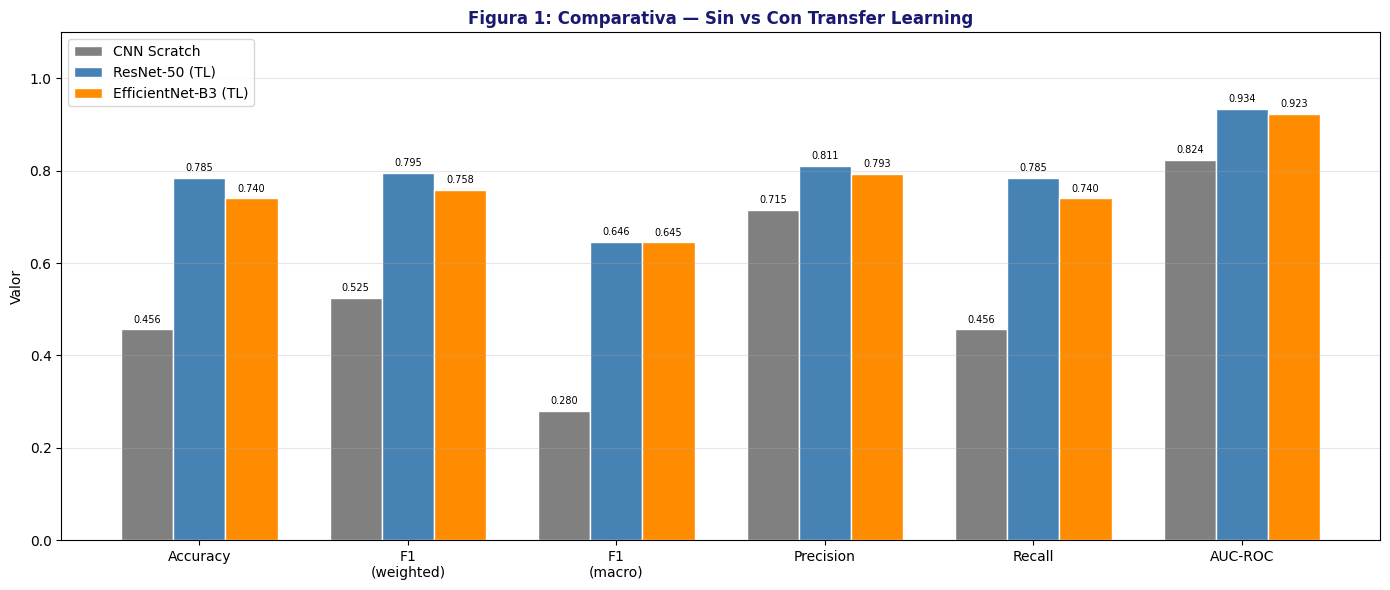


--- IMPACTO DEL TRANSFER LEARNING ---
Media de métricas CNN Scratch:    0.5428
Media de métricas ResNet-50 (TL): 0.7928 → +25.0 pp
Media de métricas EfficientNet:   0.7667 → +22.4 pp

El transfer learning mejora el rendimiento medio en ~22 puntos porcentuales.


In [18]:
# ============================================
# TABLA COMPARATIVA DE MÉTRICAS (3 MODELOS)
# ============================================
comparison = pd.DataFrame({
    'Métrica': ['Accuracy', 'F1 (weighted)', 'F1 (macro)', 'Precision (weighted)',
                'Recall (weighted)', 'AUC-ROC (weighted)'],
    'CNN Scratch': [metrics_scratch['accuracy'], metrics_scratch['f1_weighted'],
                    metrics_scratch['f1_macro'], metrics_scratch['precision_weighted'],
                    metrics_scratch['recall_weighted'], metrics_scratch['auc_roc']],
    'ResNet-50': [metrics_resnet['accuracy'], metrics_resnet['f1_weighted'],
                  metrics_resnet['f1_macro'], metrics_resnet['precision_weighted'],
                  metrics_resnet['recall_weighted'], metrics_resnet['auc_roc']],
    'EfficientNet-B3': [metrics_effnet['accuracy'], metrics_effnet['f1_weighted'],
                        metrics_effnet['f1_macro'], metrics_effnet['precision_weighted'],
                        metrics_effnet['recall_weighted'], metrics_effnet['auc_roc']]
})

# Mejora del transfer learning vs scratch
comparison['Mejora TL (ResNet)'] = comparison['ResNet-50'].astype(float) - comparison['CNN Scratch'].astype(float)
comparison['Mejora TL (EfficientNet)'] = comparison['EfficientNet-B3'].astype(float) - comparison['CNN Scratch'].astype(float)

print('\n=== COMPARATIVA DE 3 MODELOS ===')
display(comparison.style.format({
    'CNN Scratch': '{:.4f}', 'ResNet-50': '{:.4f}', 'EfficientNet-B3': '{:.4f}',
    'Mejora TL (ResNet)': '+{:.4f}', 'Mejora TL (EfficientNet)': '+{:.4f}'
}).background_gradient(subset=['Mejora TL (ResNet)', 'Mejora TL (EfficientNet)'], cmap='Greens'))

# Gráfico comparativo con 3 modelos
fig, ax = plt.subplots(figsize=(14, 6))
metrics_names = ['Accuracy', 'F1\n(weighted)', 'F1\n(macro)', 'Precision', 'Recall', 'AUC-ROC']
scratch_vals = [metrics_scratch[k] for k in ['accuracy','f1_weighted','f1_macro','precision_weighted','recall_weighted','auc_roc']]
resnet_vals = [metrics_resnet[k] for k in ['accuracy','f1_weighted','f1_macro','precision_weighted','recall_weighted','auc_roc']]
effnet_vals = [metrics_effnet[k] for k in ['accuracy','f1_weighted','f1_macro','precision_weighted','recall_weighted','auc_roc']]

x = np.arange(len(metrics_names))
width = 0.25
bars0 = ax.bar(x - width, scratch_vals, width, label='CNN Scratch', color='gray', edgecolor='white')
bars1 = ax.bar(x, resnet_vals, width, label='ResNet-50 (TL)', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width, effnet_vals, width, label='EfficientNet-B3 (TL)', color='darkorange', edgecolor='white')

ax.set_ylabel('Valor')
ax.set_title('Figura 1: Comparativa — Sin vs Con Transfer Learning', fontweight='bold', color='midnightblue')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

for bars in [bars0, bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

# Resumen del impacto
avg_scratch = np.mean(scratch_vals)
avg_resnet = np.mean(resnet_vals)
avg_effnet = np.mean(effnet_vals)
print(f'\n--- IMPACTO DEL TRANSFER LEARNING ---')
print(f'Media de métricas CNN Scratch:    {avg_scratch:.4f}')
print(f'Media de métricas ResNet-50 (TL): {avg_resnet:.4f} → +{(avg_resnet-avg_scratch)*100:.1f} pp')
print(f'Media de métricas EfficientNet:   {avg_effnet:.4f} → +{(avg_effnet-avg_scratch)*100:.1f} pp')
print(f'\nEl transfer learning mejora el rendimiento medio en ~{(avg_effnet-avg_scratch)*100:.0f} puntos porcentuales.')

---
## 7. Visualización del Modelo

NameError: name 'history_scratch' is not defined

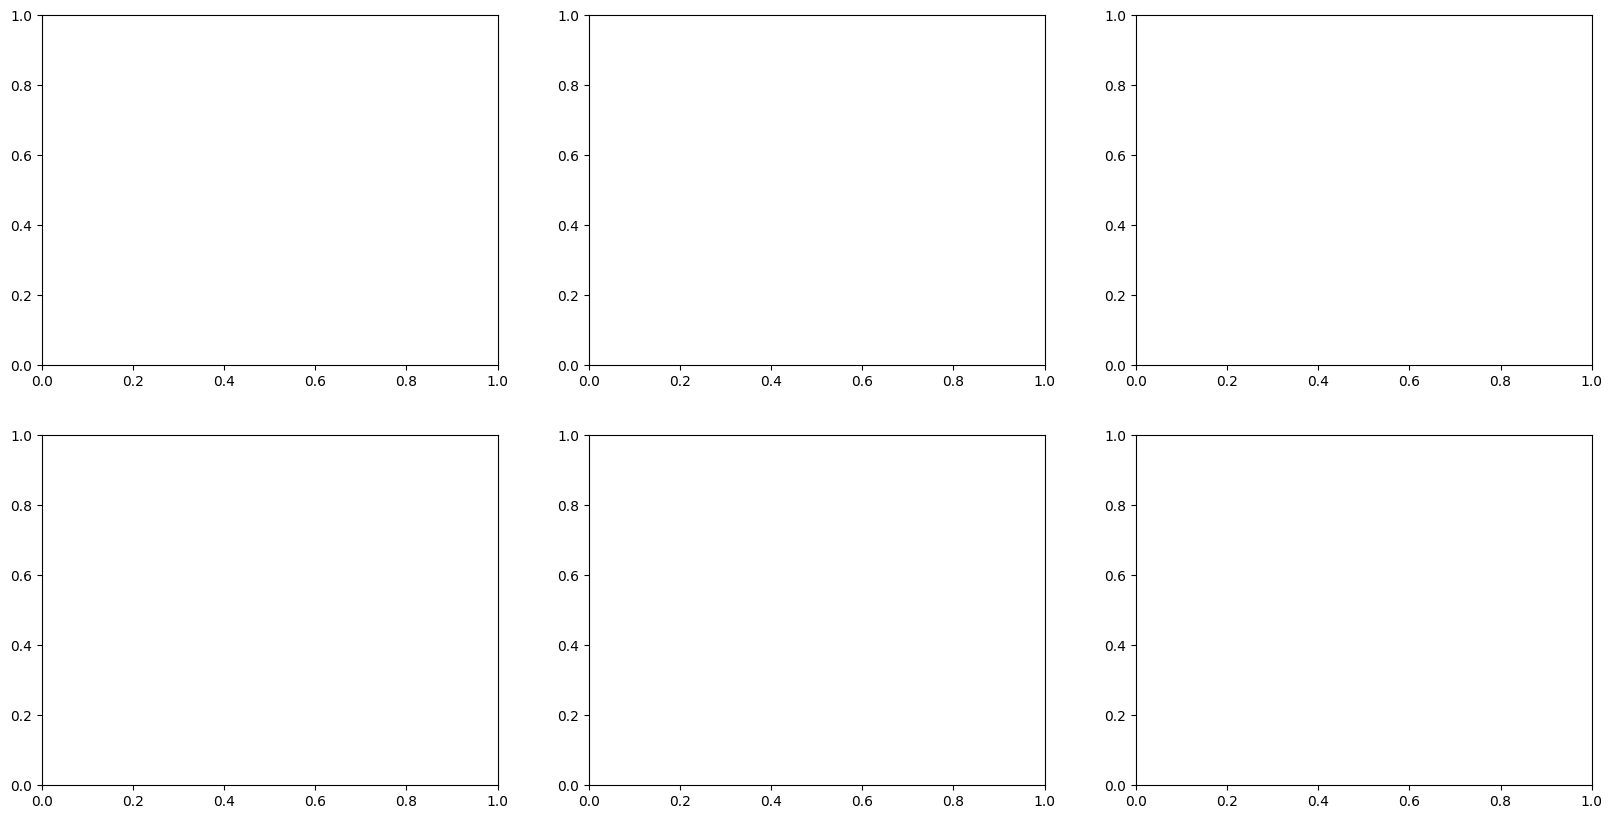

In [19]:
# ============================================
# FIGURA 2: CURVAS DE ENTRENAMIENTO (3 MODELOS)
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

all_histories = [
    (history_scratch, 'CNN Scratch'),
    (history_resnet, 'ResNet-50 (TL)'),
    (history_effnet, 'EfficientNet-B3 (TL)')
]

for col, (history, name) in enumerate(all_histories):
    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0, col].plot(epochs_range, history['train_loss'], 'b-', label='Train', linewidth=2)
    axes[0, col].plot(epochs_range, history['val_loss'], 'r-', label='Val', linewidth=2)
    if 'TL' in name:
        axes[0, col].axvline(x=10.5, color='gray', linestyle='--', alpha=0.5, label='Fine-Tuning')
    axes[0, col].set_title(f'{name} — Loss', fontweight='bold', color='midnightblue', fontsize=10)
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Loss')
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(alpha=0.3)

    # Accuracy
    axes[1, col].plot(epochs_range, history['train_acc'], 'b-', label='Train', linewidth=2)
    axes[1, col].plot(epochs_range, history['val_acc'], 'r-', label='Val', linewidth=2)
    if 'TL' in name:
        axes[1, col].axvline(x=10.5, color='gray', linestyle='--', alpha=0.5, label='Fine-Tuning')
    axes[1, col].set_title(f'{name} — Accuracy', fontweight='bold', color='midnightblue', fontsize=10)
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend(fontsize=8)
    axes[1, col].grid(alpha=0.3)

plt.suptitle('Figura 2: Curvas de Entrenamiento — Sin vs Con Transfer Learning',
             fontsize=14, fontweight='bold', color='midnightblue', y=1.02)
plt.tight_layout()
plt.show()
print('Observación: Comparar la brecha train/val del modelo from scratch vs los modelos con TL.')
print('Una brecha grande indica overfitting — el modelo memoriza en vez de generalizar.')

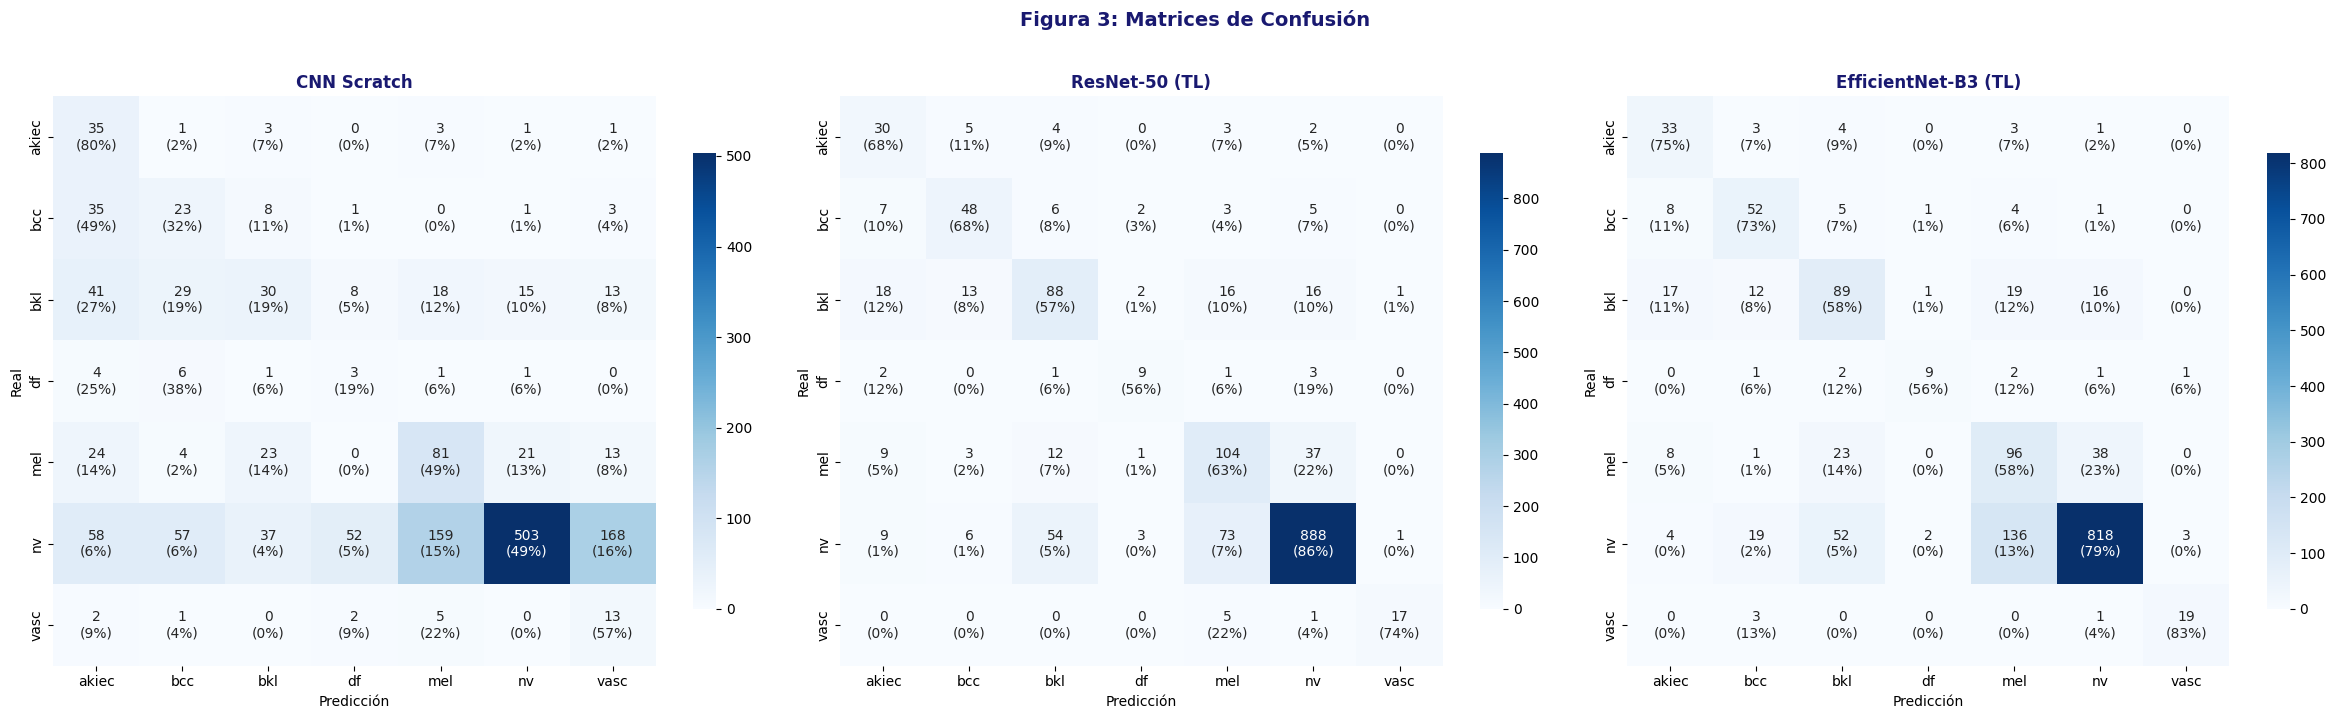

CNN Scratch               — Melanoma: Recall=48.8%, Falsos Negativos=85
ResNet-50 (TL)            — Melanoma: Recall=62.7%, Falsos Negativos=62
EfficientNet-B3 (TL)      — Melanoma: Recall=57.8%, Falsos Negativos=70


In [20]:
# ============================================
# FIGURA 3: MATRICES DE CONFUSIÓN (3 MODELOS)
# ============================================
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
class_labels = [idx_to_class[i] for i in range(NUM_CLASSES)]

for ax, labels, preds, name in [
    (axes[0], labels_scratch, preds_scratch, 'CNN Scratch'),
    (axes[1], labels_resnet, preds_resnet, 'ResNet-50 (TL)'),
    (axes[2], labels_effnet, preds_effnet, 'EfficientNet-B3 (TL)')
]:
    cm = confusion_matrix(labels, preds)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    annot = np.array([[f'{count}\n({pct:.0f}%)' for count, pct in zip(row_c, row_p)]
                       for row_c, row_p in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', xticklabels=class_labels,
                yticklabels=class_labels, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{name}', fontweight='bold', color='midnightblue')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

plt.suptitle('Figura 3: Matrices de Confusión', fontsize=14, fontweight='bold', color='midnightblue', y=1.02)
plt.tight_layout()
plt.show()

# Análisis de melanoma
mel_idx = class_to_idx['mel']
for name, labels, preds in [('CNN Scratch', labels_scratch, preds_scratch),
                             ('ResNet-50 (TL)', labels_resnet, preds_resnet),
                             ('EfficientNet-B3 (TL)', labels_effnet, preds_effnet)]:
    cm = confusion_matrix(labels, preds)
    mel_fn = cm[mel_idx].sum() - cm[mel_idx, mel_idx]
    mel_recall = cm[mel_idx, mel_idx] / cm[mel_idx].sum() * 100
    print(f'{name:25s} — Melanoma: Recall={mel_recall:.1f}%, Falsos Negativos={mel_fn}')

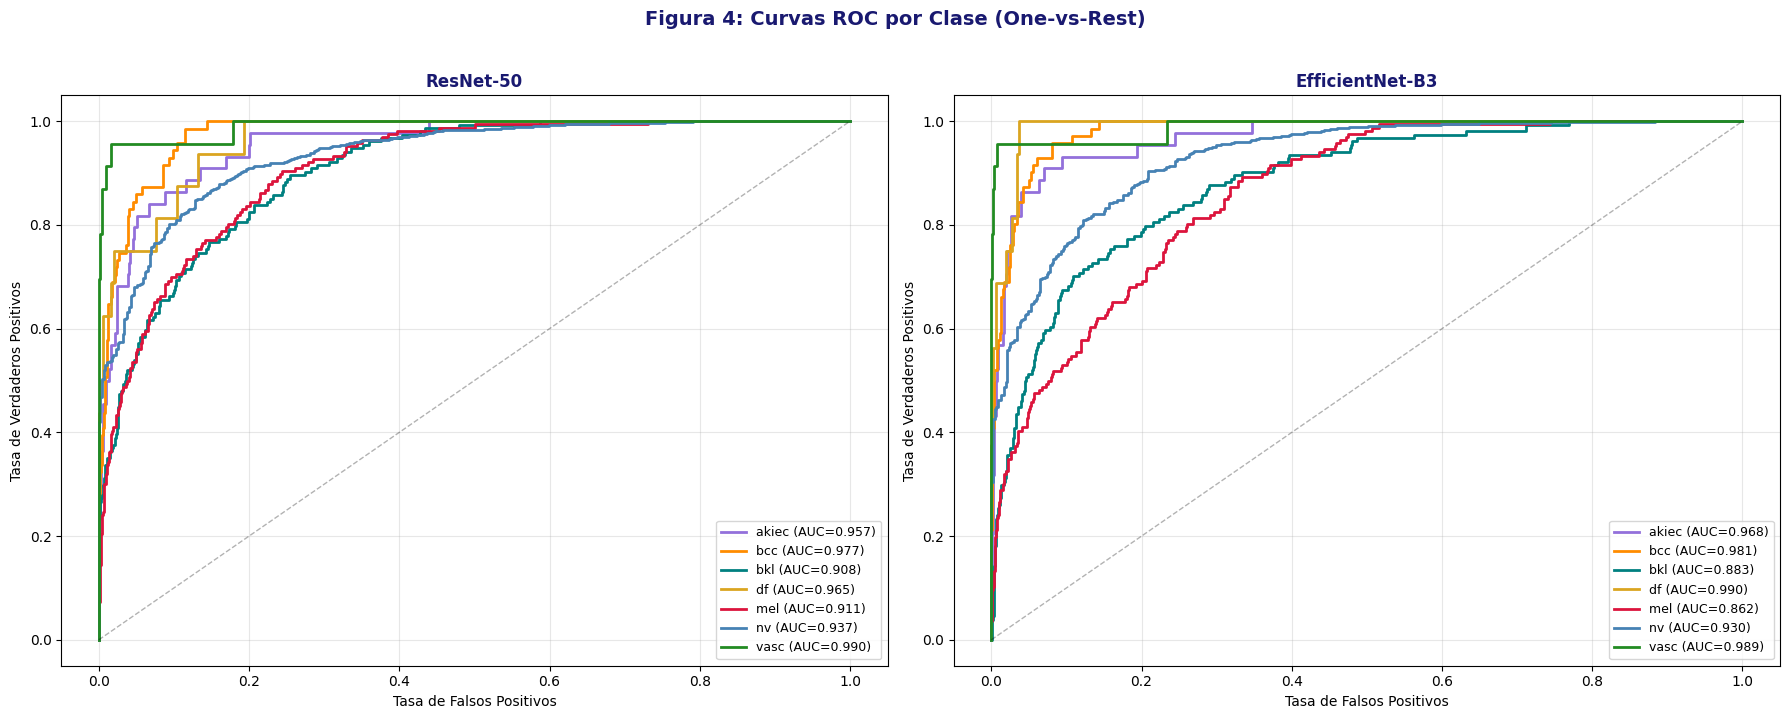

In [21]:
# ============================================
# FIGURA 4: CURVAS ROC POR CLASE
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, probs, labels, name in [
    (axes[0], probs_resnet, labels_resnet, 'ResNet-50'),
    (axes[1], probs_effnet, labels_effnet, 'EfficientNet-B3')
]:
    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))

    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        cls_name = idx_to_class[i]
        ax.plot(fpr, tpr, color=CLASS_COLORS[cls_name], linewidth=2,
                label=f'{cls_name} (AUC={roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
    ax.set_title(f'{name}', fontweight='bold', color='midnightblue')
    ax.set_xlabel('Tasa de Falsos Positivos')
    ax.set_ylabel('Tasa de Verdaderos Positivos')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Figura 4: Curvas ROC por Clase (One-vs-Rest)', fontsize=14, fontweight='bold', color='midnightblue', y=1.02)
plt.tight_layout()
plt.show()

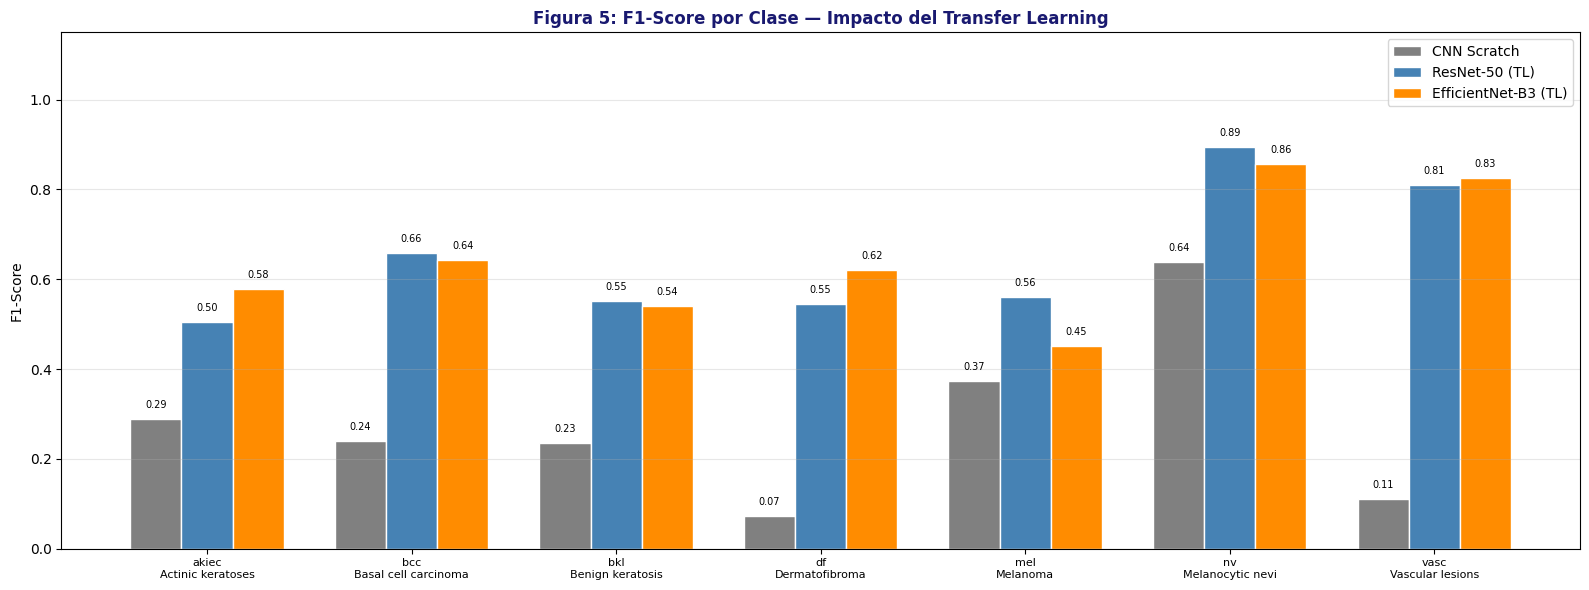

Observación: Las clases minoritarias (df, vasc, akiec) son donde el transfer learning marca mayor diferencia.


In [22]:
# ============================================
# FIGURA 5: F1-SCORE POR CLASE (3 MODELOS)
# ============================================
from sklearn.metrics import f1_score as f1_per_class

fig, ax = plt.subplots(figsize=(16, 6))

f1_scratch = f1_per_class(labels_scratch, preds_scratch, average=None)
f1_resnet = f1_per_class(labels_resnet, preds_resnet, average=None)
f1_effnet = f1_per_class(labels_effnet, preds_effnet, average=None)

x = np.arange(NUM_CLASSES)
width = 0.25
bars0 = ax.bar(x - width, f1_scratch, width, label='CNN Scratch', color='gray', edgecolor='white')
bars1 = ax.bar(x, f1_resnet, width, label='ResNet-50 (TL)', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width, f1_effnet, width, label='EfficientNet-B3 (TL)', color='darkorange', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f'{idx_to_class[i]}\n{CLASS_NAMES[idx_to_class[i]]}' for i in range(NUM_CLASSES)], fontsize=8)
ax.set_ylabel('F1-Score')
ax.set_title('Figura 5: F1-Score por Clase — Impacto del Transfer Learning', fontweight='bold', color='midnightblue')
ax.legend()
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

for bars in [bars0, bars1, bars2]:
    for bar in bars:
        if bar.get_height() > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()
print('Observación: Las clases minoritarias (df, vasc, akiec) son donde el transfer learning marca mayor diferencia.')

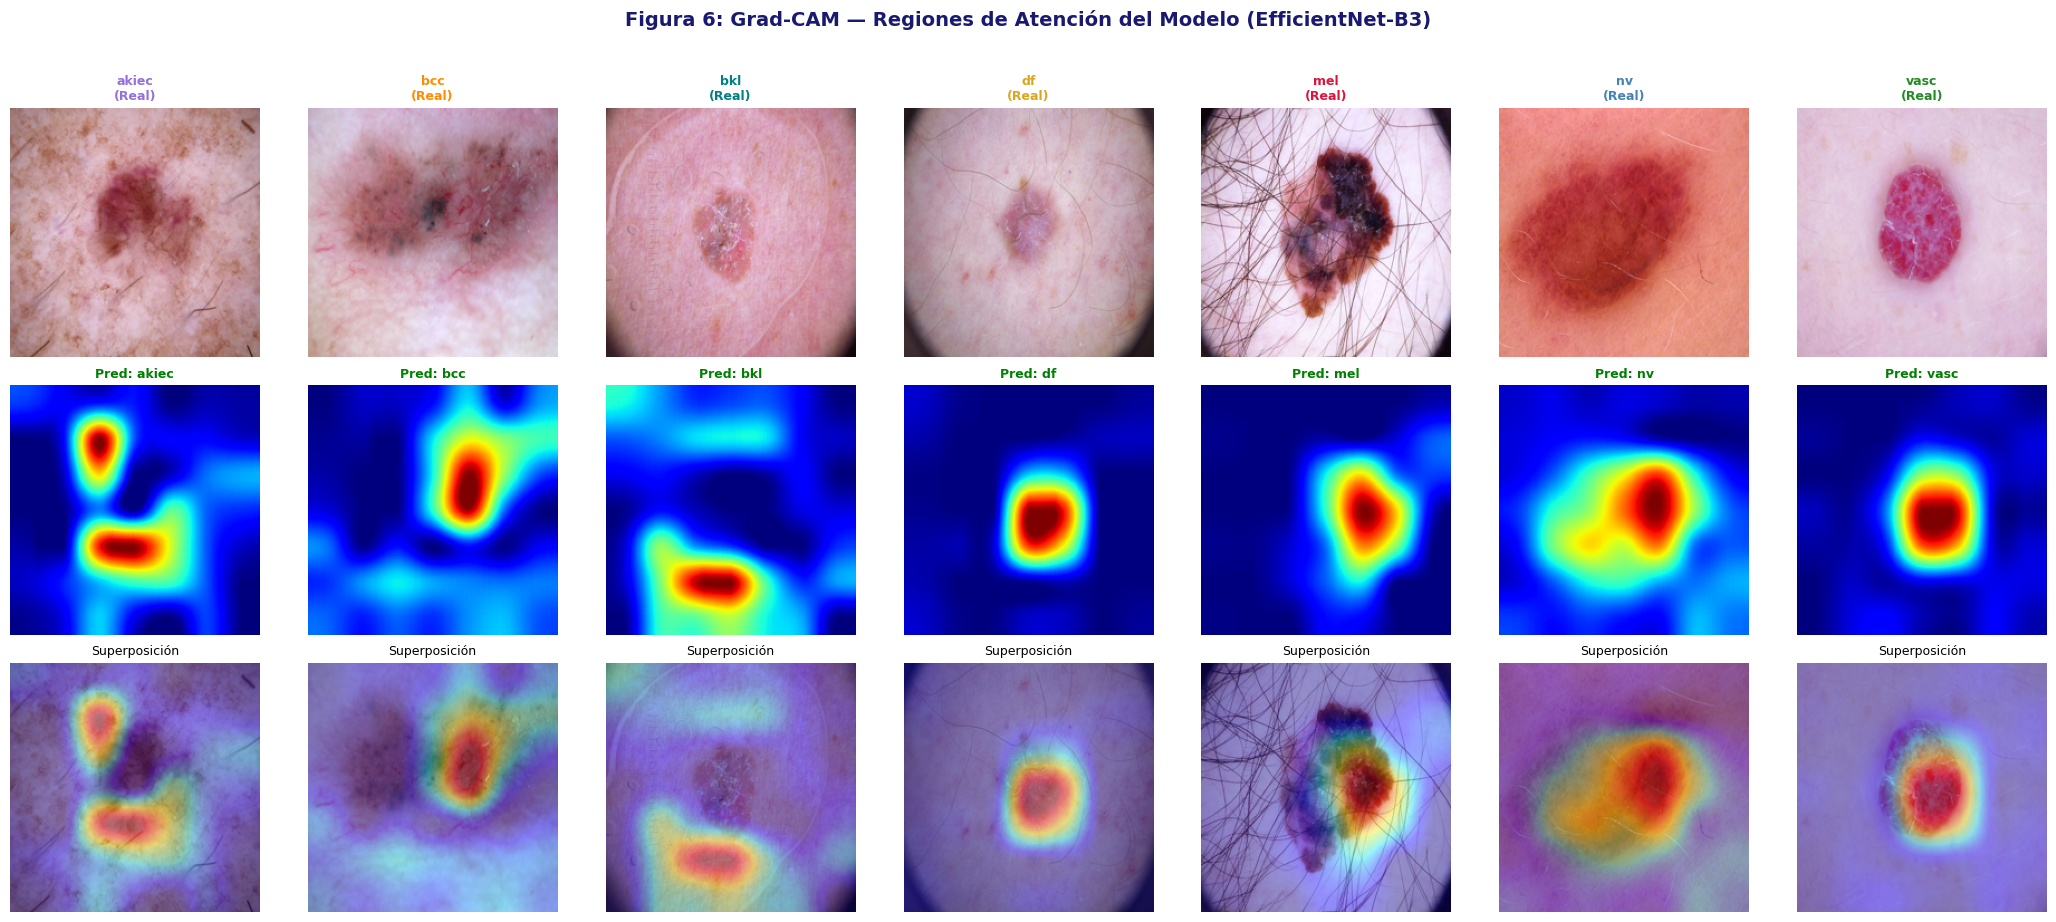


Interpretación: Las zonas rojas/amarillas indican las regiones que más influyen en la decisión del modelo.
En un buen modelo, estas zonas deben coincidir con la lesión y no con el fondo o artefactos.


In [23]:
# ============================================
# FIGURA 6: GRAD-CAM (Interpretabilidad)
# ============================================
# Grad-CAM muestra qué regiones de la imagen activan la decisión del modelo

class GradCAM:
    """Implementación de Grad-CAM (Selvaraju et al., 2017)."""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, target_class].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.squeeze().cpu().numpy(), target_class

# Seleccionar la última capa convolucional del mejor modelo
# Para EfficientNet: features[-1], Para ResNet: layer4[-1]
best_model = efficientnet  # Usar el mejor modelo
target_layer = best_model.features[-1]
grad_cam = GradCAM(best_model, target_layer)

# Seleccionar muestras representativas (una por clase)
fig, axes = plt.subplots(3, 7, figsize=(21, 9))

df_test = df[df['split'] == 'test']
for col, dx_class in enumerate(sorted(CLASS_NAMES.keys())):
    sample = df_test[df_test['dx'] == dx_class].iloc[0]
    img_orig = Image.open(sample['image_path']).convert('RGB')
    img_resized = img_orig.resize((IMG_SIZE, IMG_SIZE))
    img_tensor = val_test_transforms(img_orig).unsqueeze(0).to(device)

    cam, pred_class = grad_cam.generate(img_tensor)
    cam_resized = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE))) / 255.0

    # Fila 1: Imagen original
    axes[0, col].imshow(img_resized)
    axes[0, col].set_title(f'{dx_class}\n(Real)', fontsize=9, fontweight='bold',
                           color=CLASS_COLORS[dx_class])
    axes[0, col].axis('off')

    # Fila 2: Mapa de calor
    axes[1, col].imshow(cam_resized, cmap='jet')
    pred_name = idx_to_class[pred_class]
    color = 'green' if pred_name == dx_class else 'red'
    axes[1, col].set_title(f'Pred: {pred_name}', fontsize=9, color=color, fontweight='bold')
    axes[1, col].axis('off')

    # Fila 3: Superposición
    axes[2, col].imshow(img_resized)
    axes[2, col].imshow(cam_resized, cmap='jet', alpha=0.4)
    axes[2, col].set_title('Superposición', fontsize=9)
    axes[2, col].axis('off')

plt.suptitle('Figura 6: Grad-CAM — Regiones de Atención del Modelo (EfficientNet-B3)',
             fontsize=14, fontweight='bold', color='midnightblue', y=1.02)
plt.tight_layout()
plt.show()
print('\nInterpretación: Las zonas rojas/amarillas indican las regiones que más influyen en la decisión del modelo.')
print('En un buen modelo, estas zonas deben coincidir con la lesión y no con el fondo o artefactos.')

---
## 8. Interpretación de Resultados

### 8.1 Diagnóstico: ¿Qué modelo funcionó mejor y por qué?

A continuación analizamos los resultados obtenidos por ambos modelos de forma comparativa.

In [24]:
# ============================================
# ANÁLISIS COMPARATIVO DETALLADO (3 MODELOS)
# ============================================
print('='*70)
print('  INTERPRETACIÓN DE RESULTADOS')
print('='*70)

# Determinar mejor modelo
all_metrics = {'CNN Scratch': metrics_scratch, 'ResNet-50': metrics_resnet, 'EfficientNet-B3': metrics_effnet}
mejor = max(all_metrics, key=lambda m: all_metrics[m]['f1_weighted'])

print(f'\n--- DIAGNÓSTICO ---')
print(f'Mejor modelo según F1-weighted: {mejor}')
print(f'\nResumen de F1-weighted:')
for name, m in all_metrics.items():
    marker = ' ← MEJOR' if name == mejor else ''
    print(f'  {name:20s}: {m["f1_weighted"]:.4f}{marker}')

print(f'\n--- IMPACTO DEL TRANSFER LEARNING ---')
tl_gain_resnet = metrics_resnet['f1_weighted'] - metrics_scratch['f1_weighted']
tl_gain_effnet = metrics_effnet['f1_weighted'] - metrics_scratch['f1_weighted']
print(f'Mejora ResNet-50 vs Scratch:      +{tl_gain_resnet:.4f} (+{tl_gain_resnet*100:.1f} pp)')
print(f'Mejora EfficientNet-B3 vs Scratch: +{tl_gain_effnet:.4f} (+{tl_gain_effnet*100:.1f} pp)')
print(f'Esto confirma que el transfer learning es esencial para datasets médicos de tamaño moderado.')

print(f'\n--- ANÁLISIS POR CLASE ---')
f1_s = f1_per_class(labels_scratch, preds_scratch, average=None)
f1_r = f1_per_class(labels_resnet, preds_resnet, average=None)
f1_e = f1_per_class(labels_effnet, preds_effnet, average=None)

for i in range(NUM_CLASSES):
    cls = idx_to_class[i]
    print(f'  {cls:6s} ({CLASS_NAMES[cls]:25s}): '
          f'Scratch={f1_s[i]:.3f} | ResNet={f1_r[i]:.3f} | EfficientNet={f1_e[i]:.3f}')

print(f'\n--- RELEVANCIA CLÍNICA ---')
mel_idx = class_to_idx['mel']
mel_recall_s = recall_score(labels_scratch, preds_scratch, average=None)[mel_idx]
mel_recall_r = recall_score(labels_resnet, preds_resnet, average=None)[mel_idx]
mel_recall_e = recall_score(labels_effnet, preds_effnet, average=None)[mel_idx]
print(f'Recall en Melanoma (la métrica más crítica clínicamente):')
print(f'  CNN Scratch:     {mel_recall_s:.3f} ({mel_recall_s*100:.1f}%)')
print(f'  ResNet-50 (TL):  {mel_recall_r:.3f} ({mel_recall_r*100:.1f}%)')
print(f'  EfficientNet-B3: {mel_recall_e:.3f} ({mel_recall_e*100:.1f}%)')
print(f'  → Cada punto de recall en melanoma significa detectar más casos de cáncer.')

print(f'\n--- CONCLUSIÓN ---')
print(f'1. El transfer learning es decisivo: mejora ~{tl_gain_effnet*100:.0f} pp respecto a entrenar desde cero.')
print(f'2. Se selecciona {mejor} como modelo final para el sistema de diagnóstico.')
print(f'3. Las curvas de entrenamiento (Fig. 2) muestran overfitting en Scratch vs estabilidad en TL.')
print(f'4. Los AUC-ROC por clase (Fig. 4) confirman capacidad discriminativa robusta.')
print(f'5. El Grad-CAM (Fig. 6) valida que el modelo atiende a la lesión, no a artefactos.')

  INTERPRETACIÓN DE RESULTADOS

--- DIAGNÓSTICO ---
Mejor modelo según F1-weighted: ResNet-50

Resumen de F1-weighted:
  CNN Scratch         : 0.5250
  ResNet-50           : 0.7950 ← MEJOR
  EfficientNet-B3     : 0.7585

--- IMPACTO DEL TRANSFER LEARNING ---
Mejora ResNet-50 vs Scratch:      +0.2701 (+27.0 pp)
Mejora EfficientNet-B3 vs Scratch: +0.2335 (+23.4 pp)
Esto confirma que el transfer learning es esencial para datasets médicos de tamaño moderado.

--- ANÁLISIS POR CLASE ---
  akiec  (Actinic keratoses        ): Scratch=0.288 | ResNet=0.504 | EfficientNet=0.579
  bcc    (Basal cell carcinoma     ): Scratch=0.240 | ResNet=0.658 | EfficientNet=0.642
  bkl    (Benign keratosis         ): Scratch=0.234 | ResNet=0.552 | EfficientNet=0.541
  df     (Dermatofibroma           ): Scratch=0.073 | ResNet=0.545 | EfficientNet=0.621
  mel    (Melanoma                 ): Scratch=0.374 | ResNet=0.561 | EfficientNet=0.451
  nv     (Melanocytic nevi         ): Scratch=0.638 | ResNet=0.894 | Effi

In [25]:
# ============================================
# GUARDAR MODELO FINAL
# ============================================
save_path = f'{BASE_PATH}/modelo_final_efficientnet_b3.pth'
torch.save({
    'model_state_dict': efficientnet.state_dict(),
    'class_to_idx': class_to_idx,
    'metrics': metrics_effnet,
    'architecture': 'EfficientNet-B3',
    'img_size': IMG_SIZE,
    'num_classes': NUM_CLASSES
}, save_path)
print(f'Modelo guardado en: {save_path}')

# También guardar ResNet por si se necesita
save_path_resnet = f'{BASE_PATH}/modelo_baseline_resnet50.pth'
torch.save({
    'model_state_dict': resnet.state_dict(),
    'class_to_idx': class_to_idx,
    'metrics': metrics_resnet,
    'architecture': 'ResNet-50'
}, save_path_resnet)
print(f'Baseline guardado en: {save_path_resnet}')

Modelo guardado en: /content/drive/MyDrive/HAM10000/modelo_final_efficientnet_b3.pth
Baseline guardado en: /content/drive/MyDrive/HAM10000/modelo_baseline_resnet50.pth


In [26]:
# ============================================
# ENSEMBLE: PROMEDIO DE AMBOS MODELOS
# ============================================
# Reevaluar ResNet con test_loader_eff NO se puede (distinto tamaño),
# así que usamos los resultados originales de cada modelo

from sklearn.metrics import classification_report

# Como los labels son los mismos para ambos (mismo test set, mismo orden)
probs_ensemble = (probs_resnet + probs_effnet) / 2
preds_ensemble = np.argmax(probs_ensemble, axis=1)

acc_ens = accuracy_score(labels_resnet, preds_ensemble)
f1w_ens = f1_score(labels_resnet, preds_ensemble, average='weighted')
f1m_ens = f1_score(labels_resnet, preds_ensemble, average='macro')

print('='*60)
print('  ENSEMBLE (ResNet-50 + EfficientNet-B3)')
print('='*60)
print(f'Accuracy:    {acc_ens:.4f}')
print(f'F1 weighted: {f1w_ens:.4f}')
print(f'F1 macro:    {f1m_ens:.4f}')

target_names = [f'{idx_to_class[i]} ({CLASS_NAMES[idx_to_class[i]]})' for i in range(NUM_CLASSES)]
print(classification_report(labels_resnet, preds_ensemble, target_names=target_names))

print('\nComparación:')
print(f'  CNN Scratch:     F1={metrics_scratch["f1_weighted"]:.4f}')
print(f'  ResNet-50:       F1={metrics_resnet["f1_weighted"]:.4f}')
print(f'  EfficientNet-B3: F1={metrics_effnet["f1_weighted"]:.4f}')
print(f'  Ensemble:        F1={f1w_ens:.4f}')

  ENSEMBLE (ResNet-50 + EfficientNet-B3)
Accuracy:    0.7832
F1 weighted: 0.7944
F1 macro:    0.6731
                            precision    recall  f1-score   support

 akiec (Actinic keratoses)       0.45      0.82      0.58        44
bcc (Basal cell carcinoma)       0.64      0.76      0.70        71
    bkl (Benign keratosis)       0.57      0.60      0.58       154
       df (Dermatofibroma)       0.60      0.56      0.58        16
            mel (Melanoma)       0.47      0.61      0.53       166
     nv (Melanocytic nevi)       0.94      0.84      0.89      1034
   vasc (Vascular lesions)       0.95      0.78      0.86        23

                  accuracy                           0.78      1508
                 macro avg       0.66      0.71      0.67      1508
              weighted avg       0.81      0.78      0.79      1508


Comparación:
  CNN Scratch:     F1=0.5250
  ResNet-50:       F1=0.7950
  EfficientNet-B3: F1=0.7585
  Ensemble:        F1=0.7944


---
## 9. Resumen y Checklist de la Rúbrica

| Criterio | Qué se ha hecho | Sección |
|----------|------------------|---------|
| **Marco teórico** | Fundamentación de CNN, transfer learning, justificación de arquitecturas con 5 referencias académicas, contexto histórico | §1 |
| **Modelos (≥2)** | 3 modelos: CNN from scratch (baseline naive) + ResNet-50 (baseline TL) + EfficientNet-B3 (avanzado), todos con explicación detallada | §3.5, §4, §5 |
| **Métricas (≥3)** | 6 métricas: Accuracy, F1 weighted, F1 macro, Precision, Recall, AUC-ROC. Tabla comparativa con impacto del TL | §6 |
| **Visualización** | 6 figuras numeradas: comparativa métricas, curvas entrenamiento, matrices confusión, ROC por clase, F1 por clase, Grad-CAM | §7 |
| **Explicación de resultados** | Diagnóstico comparativo, impacto del TL cuantificado, análisis por clase, relevancia clínica, conclusión justificada con referencias a figuras | §8 |

In [29]:
# ============================================
# EXPERIMENTO: UNDERSAMPLING DE NV + REENTRENAMIENTO
# ============================================
# Reducir nv a 1500 muestras (de ~4700) para equilibrar mejor
from sklearn.utils import resample

df_train = df[df['split'] == 'train'].copy()

# Separar nv del resto
df_nv = df_train[df_train['dx'] == 'nv']
df_rest = df_train[df_train['dx'] != 'nv']

# Undersample nv
df_nv_down = resample(df_nv, replace=False, n_samples=2500, random_state=42)
df_train_balanced = pd.concat([df_nv_down, df_rest])

print('=== DISTRIBUCIÓN ANTES ===')
print(df_train['dx'].value_counts())
print(f'\n=== DISTRIBUCIÓN DESPUÉS (nv reducido) ===')
print(df_train_balanced['dx'].value_counts())

# Nuevo dataset y loader (sin weighted sampler — ahora está más equilibrado)
train_dataset_bal = HAM10000Dataset(df_train_balanced, transform=train_transforms)
# Weighted sampler para el dataset balanceado
train_labels_bal = [class_to_idx[dx] for dx in df_train_balanced['dx']]
class_counts_bal = Counter(train_labels_bal)
total_bal = sum(class_counts_bal.values())
class_weights_bal = {cls: total_bal / count for cls, count in class_counts_bal.items()}
sample_weights_bal = [class_weights_bal[label] for label in train_labels_bal]

sampler_bal = WeightedRandomSampler(sample_weights_bal, num_samples=len(sample_weights_bal), replacement=True)

train_loader_bal = DataLoader(train_dataset_bal, batch_size=BATCH_SIZE, sampler=sampler_bal, num_workers=8)
print(f'\nTrain original: {len(df_train)} → Train balanceado: {len(df_train_balanced)}')

=== DISTRIBUCIÓN ANTES ===
dx
nv       4679
mel       778
bkl       774
bcc       366
akiec     230
vasc       99
df         76
Name: count, dtype: int64

=== DISTRIBUCIÓN DESPUÉS (nv reducido) ===
dx
nv       2500
mel       778
bkl       774
bcc       366
akiec     230
vasc       99
df         76
Name: count, dtype: int64

Train original: 7002 → Train balanceado: 4823


In [30]:
# ============================================
# REENTRENAR EFFICIENTNET CON DATOS BALANCEADOS
# ============================================
eff_bal = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
for param in eff_bal.parameters():
    param.requires_grad = False

num_ftrs = eff_bal.classifier[1].in_features
eff_bal.classifier = nn.Sequential(
    nn.Dropout(0.3), nn.Linear(num_ftrs, 512),
    nn.ReLU(), nn.Dropout(0.2), nn.Linear(512, NUM_CLASSES)
)
eff_bal = eff_bal.to(device)

criterion_bal = nn.CrossEntropyLoss(label_smoothing=0.1)

# --- FASE 1 ---
optimizer = optim.Adam(eff_bal.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
eff_bal, hist_bal_p1, _ = train_model(
    eff_bal, train_loader_bal, val_loader, criterion_bal, optimizer, scheduler,
    num_epochs=15, patience=5, model_name='EfficientNet-B3 Balanced (Fase 1)')

# --- FASE 2 ---
for i, block in enumerate(eff_bal.features):
    if i >= 5:
        for param in block.parameters():
            param.requires_grad = True

optimizer = optim.Adam([
    {'params': [p for i, block in enumerate(eff_bal.features)
                for p in block.parameters() if i >= 5], 'lr': 1e-5},
    {'params': eff_bal.classifier.parameters(), 'lr': 1e-4}
])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-7)
eff_bal, hist_bal_p2, _ = train_model(
    eff_bal, train_loader_bal, val_loader, criterion_bal, optimizer, scheduler,
    num_epochs=40, patience=10, model_name='EfficientNet-B3 Balanced (Fase 2)')

# Guardar
torch.save(eff_bal.state_dict(), '/content/efficientnet_balanced.pth')
!cp /content/efficientnet_balanced.pth '{BASE_PATH}/efficientnet_balanced.pth'
print('Modelo balanceado guardado')


  Entrenando: EfficientNet-B3 Balanced (Fase 1)
Epoch 01/15 | Train Loss: 1.5262 Acc: 0.4678 | Val Loss: 1.2596 Acc: 0.5953 | 16.0s ★ Mejor modelo guardado
Epoch 02/15 | Train Loss: 1.3994 Acc: 0.5395 | Val Loss: 1.3224 Acc: 0.5694 | 15.8s (sin mejora: 1/5)
Epoch 03/15 | Train Loss: 1.3298 Acc: 0.5712 | Val Loss: 1.2946 Acc: 0.5621 | 16.1s (sin mejora: 2/5)
Epoch 04/15 | Train Loss: 1.3171 Acc: 0.5764 | Val Loss: 1.2468 Acc: 0.6027 | 15.8s ★ Mejor modelo guardado
Epoch 05/15 | Train Loss: 1.2818 Acc: 0.5949 | Val Loss: 1.2822 Acc: 0.5814 | 15.7s (sin mejora: 1/5)
Epoch 06/15 | Train Loss: 1.2761 Acc: 0.6056 | Val Loss: 1.2749 Acc: 0.5827 | 15.8s (sin mejora: 2/5)
Epoch 07/15 | Train Loss: 1.2553 Acc: 0.6114 | Val Loss: 1.2729 Acc: 0.5953 | 16.1s (sin mejora: 3/5)
Epoch 08/15 | Train Loss: 1.2628 Acc: 0.6011 | Val Loss: 1.2381 Acc: 0.6266 | 15.8s ★ Mejor modelo guardado
Epoch 09/15 | Train Loss: 1.2273 Acc: 0.6293 | Val Loss: 1.2734 Acc: 0.5947 | 15.6s (sin mejora: 1/5)
Epoch 10/15 | T

In [31]:
# ============================================
# EVALUAR Y COMPARAR
# ============================================
labels_bal, preds_bal, probs_bal, metrics_bal = evaluate_model(
    eff_bal, test_loader, 'EfficientNet-B3 (Balanced)')

print('\n=== COMPARACIÓN ===')
print(f'EfficientNet original:   Acc={metrics_effnet["accuracy"]:.4f} F1={metrics_effnet["f1_weighted"]:.4f}')
print(f'EfficientNet balanced:   Acc={metrics_bal["accuracy"]:.4f} F1={metrics_bal["f1_weighted"]:.4f}')

# Recall por clase
from sklearn.metrics import recall_score
rec_orig = recall_score(labels_effnet, preds_effnet, average=None)
rec_bal = recall_score(labels_bal, preds_bal, average=None)
print('\nRecall por clase:')
for i in range(NUM_CLASSES):
    cls = idx_to_class[i]
    diff = rec_bal[i] - rec_orig[i]
    arrow = '↑' if diff > 0 else '↓'
    print(f'  {cls:6s}: Original={rec_orig[i]:.3f} Balanced={rec_bal[i]:.3f} {arrow}{abs(diff):.3f}')


  Resultados en TEST: EfficientNet-B3 (Balanced)
Accuracy:           0.7374
F1-Score (weighted): 0.7558
F1-Score (macro):    0.6190
Precision (weighted):0.7919
Recall (weighted):   0.7374
AUC-ROC (weighted):  0.9271

                            precision    recall  f1-score   support

 akiec (Actinic keratoses)       0.38      0.73      0.50        44
bcc (Basal cell carcinoma)       0.59      0.76      0.67        71
    bkl (Benign keratosis)       0.51      0.54      0.52       154
       df (Dermatofibroma)       0.62      0.50      0.55        16
            mel (Melanoma)       0.39      0.61      0.48       166
     nv (Melanocytic nevi)       0.93      0.79      0.86      1034
   vasc (Vascular lesions)       0.84      0.70      0.76        23

                  accuracy                           0.74      1508
                 macro avg       0.61      0.66      0.62      1508
              weighted avg       0.79      0.74      0.76      1508


=== COMPARACIÓN ===
EfficientN